### Training on the other Boolean functions

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
# Generating n-bit numbers
def generate_n_bit_numbers(n):
    # return [list(map(int, bin(i)[2:].zfill(n))) for i in range(2**n)]
    return [list(map(int, bin(i)[2:].zfill(n))) for i in range(2**n)]

x_2_list = generate_n_bit_numbers(2)
x_4_list = generate_n_bit_numbers(4)
x_5_list = generate_n_bit_numbers(5)

x_2 = np.array(x_2_list)
x_4 = np.array(x_4_list)
x_5 = np.array(x_5_list)
# print(x_2_list)

In [17]:
# XOR function
def xor_function(x):
    y = [int(np.bitwise_xor.reduce(seq)) for seq in x]
    return y

# Palindrome function
def palindrome_function(x):
    y = [int(seq == seq[::-1]) for seq in x]
    return y

# Even Parity function
def even_parity_function(x):
    y = [int(sum(seq) % 2 == 0) for seq in x]
    return y

x_2_xor_y = np.array(xor_function(x_2_list))

x_4_palindrome_y = np.array(palindrome_function(x_4_list))
x_5_palindrome_y = np.array(palindrome_function(x_5_list))

x_4_even_parity_y = np.array(even_parity_function(x_4_list))
x_5_even_parity_y = np.array(even_parity_function(x_5_list))

In [18]:
# Activation functions and their derivatives
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(a):
    return a * (1 - a)      # Here, a[i] = sigmoid(z[i])

def relu(x):
    return np.maximum(0, x)

def relu_derivative(a):
    return np.where(a > 0, 1, 0)    # Here, a[i] = relu(z[i])

# Loss functions and their derivatives
def mse(y, y_hat):
    assert(y.shape == y_hat.shape)
    return np.mean((y - y_hat)**2)

def bce(y, y_hat):
    assert(y.shape == y_hat.shape)
    return -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))

In [21]:
# Neural Network class with all activation functions being sigmoid
class SigmoidNN:
    def __init__(self, arch, x, y, lr=0.1, epochs=1000, loss_func="bce"):
        self.arch = arch
        self.x = x
        self.no_of_samples = x.shape[0]  # M samples
        self.y = y
        
        if len(y.shape) == 1:
            self.y = y.reshape(-1, 1)
            y = self.y
    
        assert(x.shape[0] == y.shape[0])
        assert(x.shape[1] == arch[0])   # x.shape: (M, arch[0])
        assert(arch[-1] == y.shape[1])  # y.shape: (M, arch[-1]), where arch[-1] = 1 for binary classification

        self.lr = lr
        self.epochs = epochs
        self.loss_func = loss_func
        self.losses = []

        self.W = [np.random.rand(arch[i], arch[i+1]) for i in range(len(arch)-1)]   # W[i] shape: (arch[i], arch[i+1])
        self.b = [np.random.rand(1, arch[i+1]) for i in range(len(arch)-1)]         # b[i] shape: (1, arch[i+1])

    def forward(self):
        self.z = []
        self.a = [self.x]
        for i in range(len(self.arch)-1):
            self.z.append(np.dot(self.a[i], self.W[i]) + self.b[i])     # z[i] shape: (M, arch[i+1])
            self.a.append(sigmoid(self.z[i]))                           # a[i] shape: (M, arch[i])
        return self.a[-1]
    
    def backward(self):
        y = self.y
        if self.loss_func == "bce":
            self.dz = [(self.a[-1] - y) / self.no_of_samples]
        elif self.loss_func == "mse":
            self.dz = [2*(self.a[-1] - y) * sigmoid_derivative(self.a[-1]) / self.no_of_samples]
        else:
            raise ValueError("Invalid loss function")

        for i in range(len(self.arch)-2, -1, -1):
            self.dW = np.dot(self.a[i].T, self.dz[-1])              # dW shape: (arch[i], M) x (M, arch[i+1]) = (arch[i], arch[i+1])
            assert(self.dW.shape == self.W[i].shape)
            self.db = np.sum(self.dz[-1], axis=0, keepdims=True)    # db shape: (1, arch[i+1])
            assert(self.db.shape == self.b[i].shape)
            dz_temp = np.dot(self.dz[-1], self.W[i].T) * sigmoid_derivative(self.a[i])  # dz_temp shape: (M, arch[i])
            assert(dz_temp.shape == self.a[i].shape)
            self.dz.append(dz_temp)
            self.W[i] -= self.lr * self.dW
            self.b[i] -= self.lr * self.db

    def train(self, print_epoch=100):
        for _ in range(self.epochs):
            y_hat = self.forward()
            self.backward()

            if self.loss_func == "bce":
                self.losses.append(bce(self.y, y_hat))
            elif self.loss_func == "mse":
                self.losses.append(mse(self.y, y_hat))
            
            if _ % print_epoch == 0:
                print(f"Epoch {_}: Loss = {self.losses[-1]}, Accuracy = {self.accuracy(y_hat)}")
    
    def predict(self, y_hat):
        return (y_hat > 0.5).astype(int)
    
    def plot_loss(self):
        plt.plot(self.losses)
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Loss vs Epoch")
        plt.show()

    def accuracy(self, y_hat):
        assert(y_hat.shape == self.y.shape)
        y_pred = self.predict(y_hat)
        assert(y_pred.shape == self.y.shape)
        return np.mean(self.y == y_pred)
    
    def print_weights_and_biases(self):
        for i in range(len(self.W)):
            print(f"Layer {i+1}") 
            print(f"W = {self.W[i]}") 
            print(f"b = {self.b[i]}")


Epoch 0: Loss = 0.3339336766453551, Accuracy = 0.5
Epoch 10000: Loss = 0.018310597904973535, Accuracy = 1.0
Epoch 20000: Loss = 0.0027667463595305204, Accuracy = 1.0
Epoch 30000: Loss = 0.0014054869394577137, Accuracy = 1.0
Epoch 40000: Loss = 0.0009288664648976189, Accuracy = 1.0
Epoch 50000: Loss = 0.000689570779873779, Accuracy = 1.0
Epoch 60000: Loss = 0.0005466018423053479, Accuracy = 1.0
Epoch 70000: Loss = 0.00045187808092669336, Accuracy = 1.0
Epoch 80000: Loss = 0.0003846530405840642, Accuracy = 1.0
Epoch 90000: Loss = 0.00033454473152116427, Accuracy = 1.0


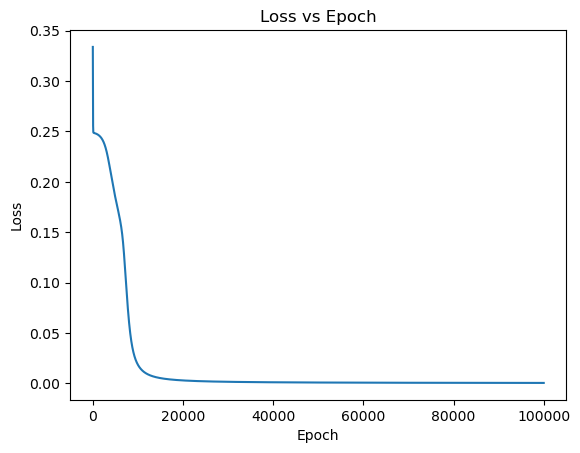

Layer 1
W = [[6.49200205 4.56319403]
 [6.53685085 4.57374504]]
b = [[-2.89734312 -7.01143257]]
Layer 2
W = [[  9.61297382]
 [-10.33559367]]
b = [[-4.43913582]]


In [22]:
nn_xor_mse = SigmoidNN([2,2,1], x_2, x_2_xor_y, 0.1, 100000, loss_func="mse")
nn_xor_mse.train(print_epoch=10000)
nn_xor_mse.plot_loss()
nn_xor_mse.print_weights_and_biases()

Epoch 0: Loss = 0.8226911292981457, Accuracy = 0.5
Epoch 10000: Loss = 0.023092177244626817, Accuracy = 1.0
Epoch 20000: Loss = 0.006853793523304889, Accuracy = 1.0
Epoch 30000: Loss = 0.003978199147370699, Accuracy = 1.0
Epoch 40000: Loss = 0.0027941333486786574, Accuracy = 1.0
Epoch 50000: Loss = 0.002150501150519545, Accuracy = 1.0
Epoch 60000: Loss = 0.0017466811845401017, Accuracy = 1.0
Epoch 70000: Loss = 0.0014699315667986367, Accuracy = 1.0
Epoch 80000: Loss = 0.0012685361427473521, Accuracy = 1.0
Epoch 90000: Loss = 0.0011154615495878413, Accuracy = 1.0


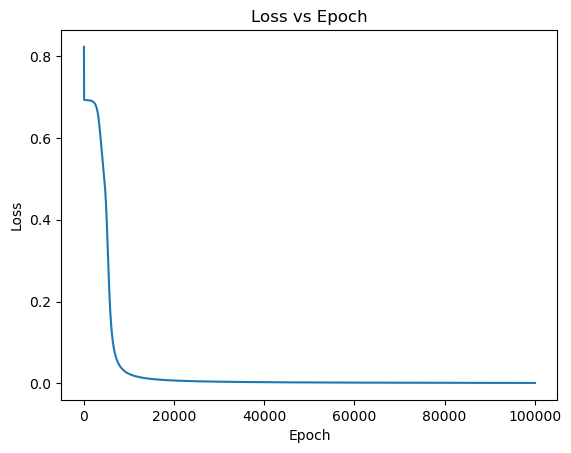

Layer 1
W = [[7.91585349 6.13948087]
 [7.91137206 6.13864261]]
b = [[-3.66230757 -9.37815159]]
Layer 2
W = [[ 14.8495602 ]
 [-15.63006054]]
b = [[-7.02992479]]


In [23]:
nn_xor_bce = SigmoidNN([2,2,1], x_2, x_2_xor_y, 0.1, 100000, loss_func="bce")
nn_xor_bce.train(print_epoch=10000)
nn_xor_bce.plot_loss()
nn_xor_bce.print_weights_and_biases()

Epoch 0: Loss = 0.44117720763179175, Accuracy = 0.25
Epoch 10000: Loss = 0.17767239683547653, Accuracy = 0.75
Epoch 20000: Loss = 0.13047469228619857, Accuracy = 0.875
Epoch 30000: Loss = 0.0700487973975117, Accuracy = 0.9375
Epoch 40000: Loss = 0.053632943741761474, Accuracy = 0.9375
Epoch 50000: Loss = 0.03148924309908763, Accuracy = 1.0
Epoch 60000: Loss = 0.01982891122718152, Accuracy = 1.0
Epoch 70000: Loss = 0.01435307077335493, Accuracy = 1.0
Epoch 80000: Loss = 0.011112965991132658, Accuracy = 1.0
Epoch 90000: Loss = 0.008997264228187649, Accuracy = 1.0


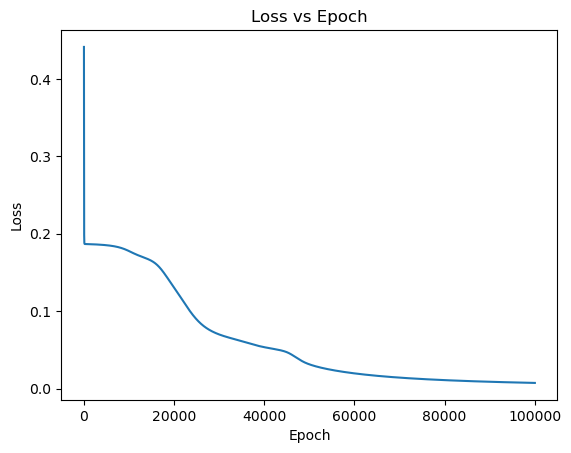

Layer 1
W = [[ 2.00984671  8.44207474  1.31864567]
 [ 8.67519244  0.82059007  1.31242261]
 [ 8.31211256 -2.96028478  1.2159135 ]
 [-3.76124175  7.90986881  1.21505943]]
b = [[-2.38544161 -1.76391176 -3.14456348]]
Layer 2
W = [[-10.19554806]
 [-10.25700728]
 [ 18.74187598]]
b = [[5.7148732]]


In [24]:
nn_pal_4_mse = SigmoidNN([4,3,1], x_4, x_4_palindrome_y, 0.1, 100000, loss_func="mse")
nn_pal_4_mse.train(print_epoch=10000)
nn_pal_4_mse.plot_loss()
nn_pal_4_mse.print_weights_and_biases()

Epoch 0: Loss = 1.518025509463747, Accuracy = 0.25
Epoch 10000: Loss = 0.43171083968043683, Accuracy = 0.8125
Epoch 20000: Loss = 0.2201323818532114, Accuracy = 0.875
Epoch 30000: Loss = 0.18802379336226457, Accuracy = 0.875
Epoch 40000: Loss = 0.1816456523713747, Accuracy = 0.875
Epoch 50000: Loss = 0.17905136954486006, Accuracy = 0.875
Epoch 60000: Loss = 0.17765328150121568, Accuracy = 0.875
Epoch 70000: Loss = 0.17677889650562872, Accuracy = 0.875
Epoch 80000: Loss = 0.17617764918777332, Accuracy = 0.875
Epoch 90000: Loss = 0.17573445668195367, Accuracy = 0.9375


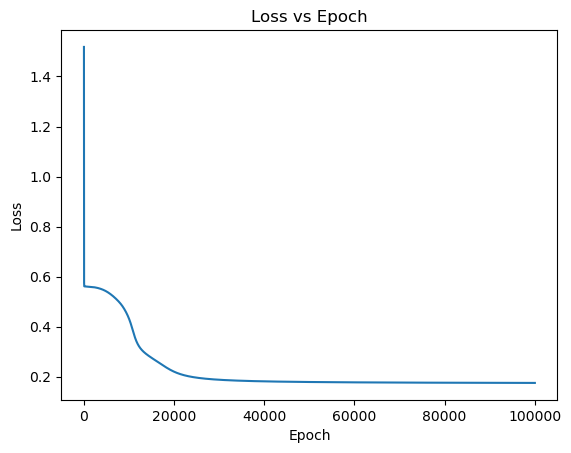

Layer 1
W = [[-5.11165415e+00 -2.07270377e-03  7.17410624e+00]
 [ 5.11315335e+00  4.68854844e+00  5.69176984e+00]
 [ 5.11398903e+00  4.68958354e+00  5.69237856e+00]
 [-5.11148392e+00 -2.07276553e-03  7.17285731e+00]]
b = [[ 7.27690181 -7.76858088 -3.31414478]]
Layer 2
W = [[-12.68600787]
 [  9.05322022]
 [-12.53620966]]
b = [[17.67426715]]


In [25]:
nn_pal_4_bce = SigmoidNN([4,3,1], x_4, x_4_palindrome_y, 0.1, 100000, loss_func="bce")
nn_pal_4_bce.train(print_epoch=10000)
nn_pal_4_bce.plot_loss()
nn_pal_4_bce.print_weights_and_biases()

Epoch 0: Loss = 0.5278165368676508, Accuracy = 0.25
Epoch 10000: Loss = 0.17754865265772368, Accuracy = 0.75
Epoch 20000: Loss = 0.15822112452549997, Accuracy = 0.8125
Epoch 30000: Loss = 0.14386665729846554, Accuracy = 0.8125
Epoch 40000: Loss = 0.12484033438802689, Accuracy = 0.8125
Epoch 50000: Loss = 0.10175531668101116, Accuracy = 0.9375
Epoch 60000: Loss = 0.08332492064688196, Accuracy = 0.9375
Epoch 70000: Loss = 0.07559058317650445, Accuracy = 0.9375
Epoch 80000: Loss = 0.07178609218567038, Accuracy = 0.9375
Epoch 90000: Loss = 0.06958066811238396, Accuracy = 0.9375
Epoch 100000: Loss = 0.06816930049513253, Accuracy = 0.9375
Epoch 110000: Loss = 0.06720026477530122, Accuracy = 0.9375
Epoch 120000: Loss = 0.06649910750110763, Accuracy = 0.9375
Epoch 130000: Loss = 0.06597091342276944, Accuracy = 0.9375
Epoch 140000: Loss = 0.06556016807731545, Accuracy = 0.9375
Epoch 150000: Loss = 0.06523246757393375, Accuracy = 0.9375
Epoch 160000: Loss = 0.06496546185942355, Accuracy = 0.9375

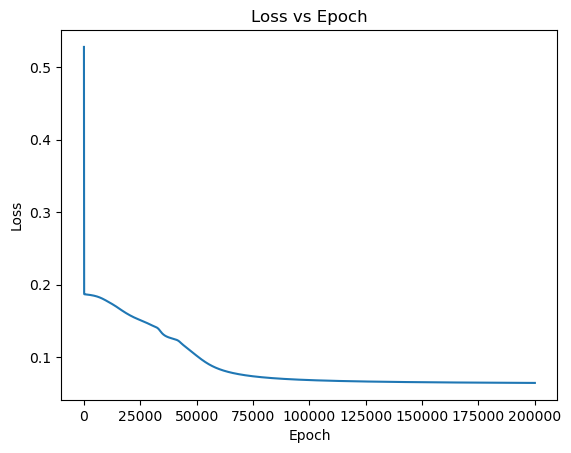

Layer 1
W = [[ 7.24951729e+00  1.32126041e+00  4.13933762e+00]
 [-1.00698032e+00  3.18310104e+00  7.15579492e+00]
 [ 1.80848946e-02 -6.58107805e-06 -2.10169945e-01]
 [-1.00580177e+00  3.18934912e+00  7.15051764e+00]
 [ 7.24791301e+00  1.32123349e+00  3.98115405e+00]]
b = [[-0.21199971 -7.60415103 -2.81075103]]
Layer 2
W = [[-11.85651103]
 [ 18.43281754]
 [ -9.4245696 ]]
b = [[8.89047234]]


In [26]:
nn_pal_5_mse = SigmoidNN([5,3,1], x_5, x_5_palindrome_y, 0.1, 200000, loss_func="mse")
nn_pal_5_mse.train(print_epoch=10000)
nn_pal_5_mse.plot_loss()
nn_pal_5_mse.print_weights_and_biases()

Epoch 0: Loss = 1.526674382030423, Accuracy = 0.25
Epoch 10000: Loss = 0.05911348579056676, Accuracy = 1.0
Epoch 20000: Loss = 0.0073154491506894495, Accuracy = 1.0
Epoch 30000: Loss = 0.003673497469818353, Accuracy = 1.0
Epoch 40000: Loss = 0.002426452239629364, Accuracy = 1.0
Epoch 50000: Loss = 0.0018038946615637247, Accuracy = 1.0
Epoch 60000: Loss = 0.0014324637465801845, Accuracy = 1.0
Epoch 70000: Loss = 0.0011863444700328742, Accuracy = 1.0
Epoch 80000: Loss = 0.0010115472909703821, Accuracy = 1.0
Epoch 90000: Loss = 0.0008811284843100264, Accuracy = 1.0


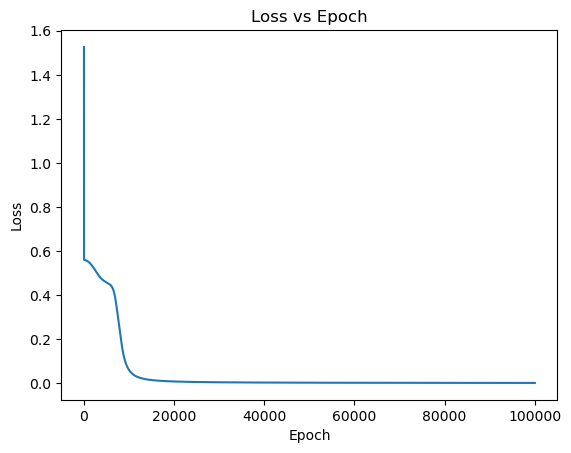

Layer 1
W = [[  5.82235101  -5.140387     5.41228913]
 [-10.3226612   11.08568502   5.28032912]
 [  0.02229441   0.02052704   0.43016818]
 [ 10.94024481 -10.4761489    4.9937123 ]
 [ -5.05690022   5.88740997   5.53886191]]
b = [[ 2.2613703   2.32292049 -0.10237838]]
Layer 2
W = [[ 16.06413212]
 [ 16.03984603]
 [-16.7523746 ]]
b = [[-7.71487238]]


In [27]:
nn_pal_5_bce = SigmoidNN([5,3,1], x_5, x_5_palindrome_y, 0.2, 100000, loss_func="bce")
nn_pal_5_bce.train(print_epoch=10000)
nn_pal_5_bce.plot_loss()
nn_pal_5_bce.print_weights_and_biases()

Epoch 0: Loss = 0.37066911013434667, Accuracy = 0.5
Epoch 10000: Loss = 0.25002550023356784, Accuracy = 0.5
Epoch 20000: Loss = 0.25000351248574526, Accuracy = 0.5625
Epoch 30000: Loss = 0.24998232465027675, Accuracy = 0.625
Epoch 40000: Loss = 0.24993710251783563, Accuracy = 0.6875
Epoch 50000: Loss = 0.2497139501793289, Accuracy = 0.6875
Epoch 60000: Loss = 0.22935155581697492, Accuracy = 0.625
Epoch 70000: Loss = 0.06881124400218083, Accuracy = 0.9375
Epoch 80000: Loss = 0.05636710169022244, Accuracy = 0.9375
Epoch 90000: Loss = 0.0535576383327795, Accuracy = 0.9375
Epoch 100000: Loss = 0.052426193602316686, Accuracy = 0.9375
Epoch 110000: Loss = 0.051828415973614476, Accuracy = 0.9375
Epoch 120000: Loss = 0.051461958968883156, Accuracy = 0.9375
Epoch 130000: Loss = 0.05121539934276645, Accuracy = 0.9375
Epoch 140000: Loss = 0.051038621445374695, Accuracy = 0.9375
Epoch 150000: Loss = 0.05090589268520301, Accuracy = 0.9375
Epoch 160000: Loss = 0.05080269044055211, Accuracy = 0.9375


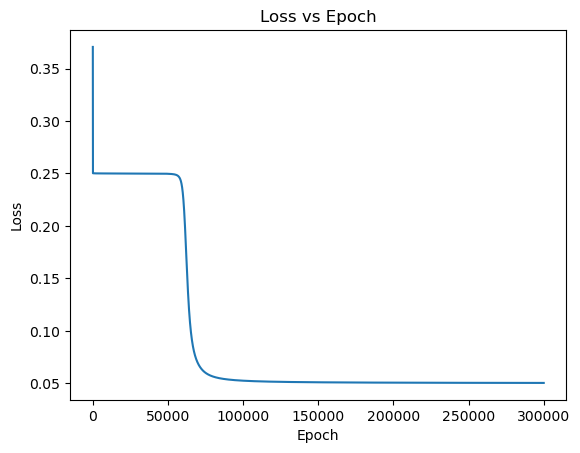

Layer 1
W = [[3.62252734 7.09684883 3.09101895 3.87027101 7.08340951]
 [3.19788259 7.0967571  3.06850582 4.18175713 7.07302278]
 [3.49973215 7.09669997 3.18809027 3.89448549 7.08100176]
 [3.48330473 7.09700616 3.2020925  3.90490489 7.08452642]]
b = [[ -1.14944862 -14.60028946  -0.80936518  -1.58245843 -10.12442095]]
Layer 2
W = [[ -4.22862732]
 [-10.08439691]
 [ -2.87787894]
 [ -6.60706361]
 [ 15.22423711]]
b = [[7.17338082]]


In [28]:
nn_even_4 = SigmoidNN([4,5,1], x_4, x_4_even_parity_y, 0.2, 300000, loss_func="mse")
nn_even_4.train(print_epoch=10000)
nn_even_4.plot_loss()
nn_even_4.print_weights_and_biases()

Epoch 0: Loss = 0.46847799496043196, Accuracy = 0.5
Epoch 10000: Loss = 0.25000481072863434, Accuracy = 0.6875
Epoch 20000: Loss = 0.2499908130448626, Accuracy = 0.625
Epoch 30000: Loss = 0.24998296999732156, Accuracy = 0.59375
Epoch 40000: Loss = 0.24997417163606278, Accuracy = 0.5625
Epoch 50000: Loss = 0.24996207449820038, Accuracy = 0.5625
Epoch 60000: Loss = 0.24994379015923665, Accuracy = 0.5625
Epoch 70000: Loss = 0.24991355576738528, Accuracy = 0.46875
Epoch 80000: Loss = 0.24985703414115162, Accuracy = 0.46875
Epoch 90000: Loss = 0.24972952702419565, Accuracy = 0.5
Epoch 100000: Loss = 0.24933641278030266, Accuracy = 0.5
Epoch 110000: Loss = 0.24712512434257422, Accuracy = 0.5
Epoch 120000: Loss = 0.22472550705467287, Accuracy = 0.5
Epoch 130000: Loss = 0.1718123449801855, Accuracy = 0.84375
Epoch 140000: Loss = 0.1464829080307693, Accuracy = 0.84375
Epoch 150000: Loss = 0.12960776347841602, Accuracy = 0.84375
Epoch 160000: Loss = 0.08835550659142258, Accuracy = 0.8125
Epoch 1

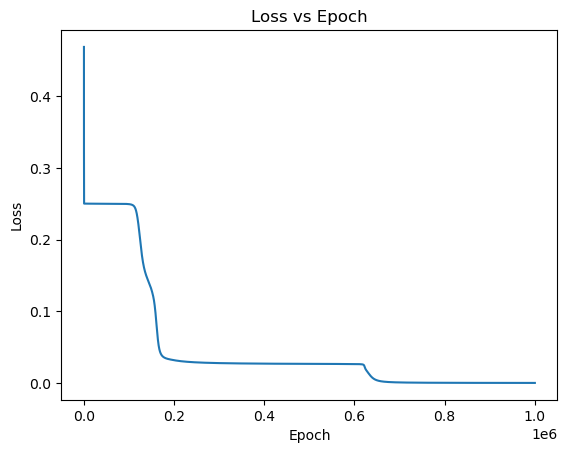

Layer 1
W = [[3.19419771 3.29322385 2.57871542 1.38629842 6.94257773 5.69796833
  5.55153342]
 [3.76288787 2.75560377 2.57815165 1.39451921 6.86187695 5.69325684
  5.52281352]
 [3.2192277  3.11038608 2.57824896 1.07698264 6.91134465 5.69539252
  5.53683718]
 [3.1925963  3.26048749 2.57856059 0.91796658 6.93765037 5.69828256
  5.54863101]
 [2.72204439 3.77983565 2.57787042 1.2884553  6.83083145 5.69130464
  5.51061093]]
b = [[ -1.41862826  -1.4337897  -11.72957847   1.7600043  -10.8095476
  -19.16782967 -12.85400118]]
Layer 2
W = [[ -6.83732933]
 [ -6.74769733]
 [-13.60421145]
 [  0.80215292]
 [ 15.26078084]
 [ 13.52608018]
 [-14.845464  ]]
b = [[5.85461834]]


In [29]:
nn_even_5 = SigmoidNN([5,7,1], x_5, x_5_even_parity_y, 0.1, 1000000, loss_func="mse")
nn_even_5.train(print_epoch=10000)
nn_even_5.plot_loss()
nn_even_5.print_weights_and_biases()

In [35]:
import numpy as np

n = 500
a = np.arange(n**2).reshape(n, n)
b = np.arange(n**2).reshape(n, n)

%timeit a.dot(b)        # 134 ms per loop
%timeit a @ b           # 71 ms per loop
%timeit np.matmul(a,b)  # 70.6 ms per loop


57.9 ms ± 1.15 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
72.8 ms ± 2.06 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
74.8 ms ± 1.01 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
